# Multi-Modal ML Data Annotation Platform
## Dataset Download · EDA · Project Setup

---

| # | Module | Dataset | Full Size | Strategy |
|---|---|---|---|---|
| 1 | 🖼️ Image | COCO 2017 | **27 GB** | Download via kagglehub → copy only **200 images** |
| 2 | 📝 Text  | IMDB 50K Movie Reviews | 27 MB | Download full → use **200 samples** for annotation |
| 3 | 🎧 Audio | RAVDESS Emotional Speech | 450 MB | Download via kagglehub → copy **100 wav files** |

## Step 1 - Install Dependencies

In [2]:
# Install kagglehub first (needed for all downloads)
!pip install -q kagglehub

# Install all project dependencies
!pip install -q streamlit pandas numpy pillow opencv-python-headless \
               streamlit-drawable-canvas plotly scikit-learn \
               librosa soundfile transformers torch torchaudio \
               seaborn matplotlib

print('All packages installed successfully')

All packages installed successfully


## Step 2 — Kaggle Authentication

**Running on Kaggle Notebooks?** You are already authenticated — skip to Step 3.

**Running locally?** Follow these steps:
1. Go to https://www.kaggle.com/settings → **API** section → click **Create New Token**
2. A `kaggle.json` file will download
3. Uncomment and run the block below

In [4]:
import os

# ── LOCAL SETUP ONLY — uncomment if NOT on Kaggle ────────────────────────────
# os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# !cp /path/to/your/downloads/kaggle.json ~/.kaggle/kaggle.json
# !chmod 600 ~/.kaggle/kaggle.json
# ─────────────────────────────────────────────────────────────────────────────

try:
    import kagglehub
    print('kagglehub ready')
    print('Auth source: ~/.kaggle/kaggle.json  OR  KAGGLE_USERNAME / KAGGLE_KEY env vars')
except ImportError:
    print('kagglehub not found - re-run Step 1')

kagglehub ready
Auth source: ~/.kaggle/kaggle.json  OR  KAGGLE_USERNAME / KAGGLE_KEY env vars


## Step 3 - Create Project Directory Structure

In [7]:
import os, shutil, glob, random, json, sqlite3
import numpy as np
import pandas as pd
import re
from PIL import Image
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# Dark theme for all matplotlib charts
matplotlib.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'text.color':       '#c9d1d9',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'axes.edgecolor':   '#30363d',
    'grid.color':       '#21262d',
})

# Create all project folders
DIRS = [
    'data/images',
    'data/images/coco_subset',
    'data/text',
    'data/audio',
    'annotations',
    'exports',
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

print('Project structure ready:')
for d in DIRS:
    print(f'  {d}/')

random.seed(42)
np.random.seed(42)
print('\n Imports done, random seeds set')

Project structure ready:
  data/images/
  data/images/coco_subset/
  data/text/
  data/audio/
  annotations/
  exports/

 Imports done, random seeds set


## Step 4 - Download All Datasets via `kagglehub`

### 4A - COCO 2017 (27 GB - we extract only 200 images)

In [8]:
import kagglehub

# How many COCO images to copy into our project
COCO_SUBSET_SIZE = 200

print(' Downloading COCO 2017 Dataset...')
print(f'   Full dataset : ~27 GB (cached by kagglehub)')
print(f'   We will copy : {COCO_SUBSET_SIZE} random images → data/images/coco_subset/')
print()

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
print("Path to dataset files:", path)

coco_path = path
print('\n COCO 2017 download complete')

   Full dataset : ~27 GB (cached by kagglehub)
   We will copy : 200 random images → data/images/coco_subset/

Path to dataset files: /kaggle/input/datasets/awsaf49/coco-2017-dataset

 COCO 2017 download complete


In [9]:
# Extract a small random subset from the huge COCO cache
all_coco_imgs = (
    glob.glob(os.path.join(coco_path, '**', '*.jpg'),  recursive=True) +
    glob.glob(os.path.join(coco_path, '**', '*.jpeg'), recursive=True)
)
print(f' Total images in cache: {len(all_coco_imgs):,}')

# Random sample
coco_subset = random.sample(all_coco_imgs, min(COCO_SUBSET_SIZE, len(all_coco_imgs)))

# Copy to project
dest = 'data/images/coco_subset'
for src in coco_subset:
    shutil.copy2(src, os.path.join(dest, os.path.basename(src)))

subset_mb = sum(
    os.path.getsize(os.path.join(dest, f))
    for f in os.listdir(dest)
) / 1e6

print(f'\n Copied {len(coco_subset)} images → {dest}/')
print(f'   Subset disk usage: ~{subset_mb:.1f} MB  (vs 27 GB full dataset)')

# Try to find COCO annotation JSON for ground-truth boxes
ann_files = (
    glob.glob(os.path.join(coco_path, '**', 'instances_val2017.json'),   recursive=True) +
    glob.glob(os.path.join(coco_path, '**', 'instances_train2017.json'), recursive=True)
)
COCO_ANN_PATH = ann_files[0] if ann_files else None
print(f'\n COCO annotation JSON: {"found → " + COCO_ANN_PATH if COCO_ANN_PATH else "not found (image-only mode)"}')

 Total images in cache: 163,957

 Copied 200 images → data/images/coco_subset/
   Subset disk usage: ~32.1 MB  (vs 27 GB full dataset)

📋 COCO annotation JSON: found → /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json


### 4B - IMDB 50K Movie Reviews (27 MB)

In [10]:
print(' Downloading IMDB Dataset of 50K Movie Reviews...')
print()

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

imdb_path = path
print('\n IMDB download complete')


Path to dataset files: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

 IMDB download complete


In [12]:
# Copy IMDB CSV into project
csv_files = glob.glob(os.path.join(imdb_path, '**', '*.csv'), recursive=True)
print(f' CSV files found: {csv_files}')

if csv_files:
    dst = 'data/text/IMDB_Dataset.csv'
    shutil.copy2(csv_files[0], dst)
    df_text = pd.read_csv(dst)
    print(f'\n Copied → {dst}')
    print(f'   Shape   : {df_text.shape}')
    print(f'   Columns : {list(df_text.columns)}')
    print()
    print(df_text.head(3).to_string())
else:
    print('  No CSV found - creating synthetic fallback dataset')
    samples = [
        ('Absolutely brilliant film. The acting was superb and gripping throughout.',    'positive'),
        ('Terrible waste of time. I walked out after 30 minutes and never looked back.', 'negative'),
        ('Decent enough for a weekend watch. Some good scenes but nothing special.',     'neutral'),
        ('One of the best films I have ever seen. A true masterpiece of cinema.',        'positive'),
        ('Poorly written, terrible acting, and a completely nonsensical plot.',          'negative'),
        ('Had some good moments but was mostly average and quite slow at times.',        'neutral'),
        ('Outstanding performances and brilliant storytelling. Highly recommend!',       'positive'),
        ('Complete garbage from start to finish. Cannot believe it got released.',       'negative'),
        ('Watchable but forgettable. Nothing you have not seen done better elsewhere.',  'neutral'),
        ('Visually stunning and emotionally powerful. This film moved me to tears.',     'positive'),
    ] * 20
    df_text = pd.DataFrame(samples[:200], columns=['review','sentiment'])
    df_text.to_csv('data/text/IMDB_Dataset.csv', index=False)
    print(f' Synthetic fallback saved (200 rows)')

 CSV files found: ['/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv']

 Copied → data/text/IMDB_Dataset.csv
   Shape   : (50000, 2)
   Columns : ['review', 'sentiment']

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

### 4C - RAVDESS Emotional Speech Audio (450 MB)

In [13]:
print('Downloading RAVDESS Emotional Speech Audio...')
print()

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Path to dataset files:", path)

ravdess_path = path
print('\nRAVDESS download complete')


Path to dataset files: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio

RAVDESS download complete


In [14]:
# RAVDESS filename pattern:
# Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav
# Emotion: 01=neutral 02=calm 03=happy 04=sad 05=angry 06=fearful 07=disgust 08=surprised

RAVDESS_EMOTIONS = {
    '01': 'neutral',  '02': 'calm',     '03': 'happy',    '04': 'sad',
    '05': 'angry',    '06': 'fearful',  '07': 'disgust',  '08': 'surprised'
}

AUDIO_SUBSET = 100  # Copy up to 100 wav files (~30 MB)

all_wav = glob.glob(os.path.join(ravdess_path, '**', '*.wav'), recursive=True)
print(f'Total RAVDESS wav files: {len(all_wav)}')

# Balanced sample across all emotions
by_emotion = {}
for f in all_wav:
    parts = os.path.basename(f).replace('.wav','').split('-')
    emo   = RAVDESS_EMOTIONS.get(parts[2], 'unknown') if len(parts) >= 3 else 'unknown'
    by_emotion.setdefault(emo, []).append(f)

per_emo    = max(1, AUDIO_SUBSET // len(by_emotion))
wav_subset = []
for emo, files in by_emotion.items():
    wav_subset.extend(random.sample(files, min(per_emo, len(files))))

# Copy to project
for src in wav_subset:
    shutil.copy2(src, os.path.join('data/audio', os.path.basename(src)))

subset_mb = sum(os.path.getsize(src) for src in wav_subset) / 1e6
print(f'Copied {len(wav_subset)} wav files → data/audio/')
print(f'   Subset disk usage: ~{subset_mb:.1f} MB  (balanced across all {len(by_emotion)} emotions)')

# Build metadata CSV
meta = []
for f in wav_subset:
    parts = os.path.basename(f).replace('.wav','').split('-')
    emo   = RAVDESS_EMOTIONS.get(parts[2], 'unknown') if len(parts) >= 3 else 'unknown'
    meta.append({
        'filename':  os.path.basename(f),
        'emotion':   emo,
        'actor_id':  parts[6] if len(parts) >= 7 else 'unknown',
        'intensity': 'normal' if len(parts) >= 4 and parts[3] == '01' else 'strong',
        'statement': parts[4] if len(parts) >= 5 else 'unknown',
    })
df_audio = pd.DataFrame(meta)
df_audio.to_csv('data/audio/audio_metadata.csv', index=False)

print(f'\n audio_metadata.csv saved ({len(df_audio)} rows)')
print('\n Emotion distribution in subset:')
print(df_audio['emotion'].value_counts().to_string())

Total RAVDESS wav files: 2880
Copied 96 wav files → data/audio/
   Subset disk usage: ~39.4 MB  (balanced across all 8 emotions)

 audio_metadata.csv saved (96 rows)

 Emotion distribution in subset:
emotion
surprised    12
neutral      12
disgust      12
fearful      12
sad          12
calm         12
happy        12
angry        12


## Step 5 - Image EDA (COCO 2017 Subset)

In [15]:
# Collect all subset images
image_files = list(dict.fromkeys(
    glob.glob('data/images/coco_subset/*.jpg') +
    glob.glob('data/images/coco_subset/*.jpeg') +
    glob.glob('data/images/coco_subset/**/*.jpg', recursive=True)
))

print(f' COCO subset: {len(image_files)} images')
if image_files:
    sizes = [os.path.getsize(f) for f in image_files]
    print(f'   Total   : {sum(sizes)/1e6:.1f} MB')
    print(f'   Average : {np.mean(sizes)/1e3:.1f} KB per image')

# Save image list CSV for the Streamlit app
pd.DataFrame({
    'image_path': image_files,
    'image_name': [os.path.basename(f) for f in image_files]
}).to_csv('data/images/image_list.csv', index=False)
print(f'\n image_list.csv saved')

 COCO subset: 200 images
   Total   : 32.1 MB
   Average : 160.4 KB per image

 image_list.csv saved


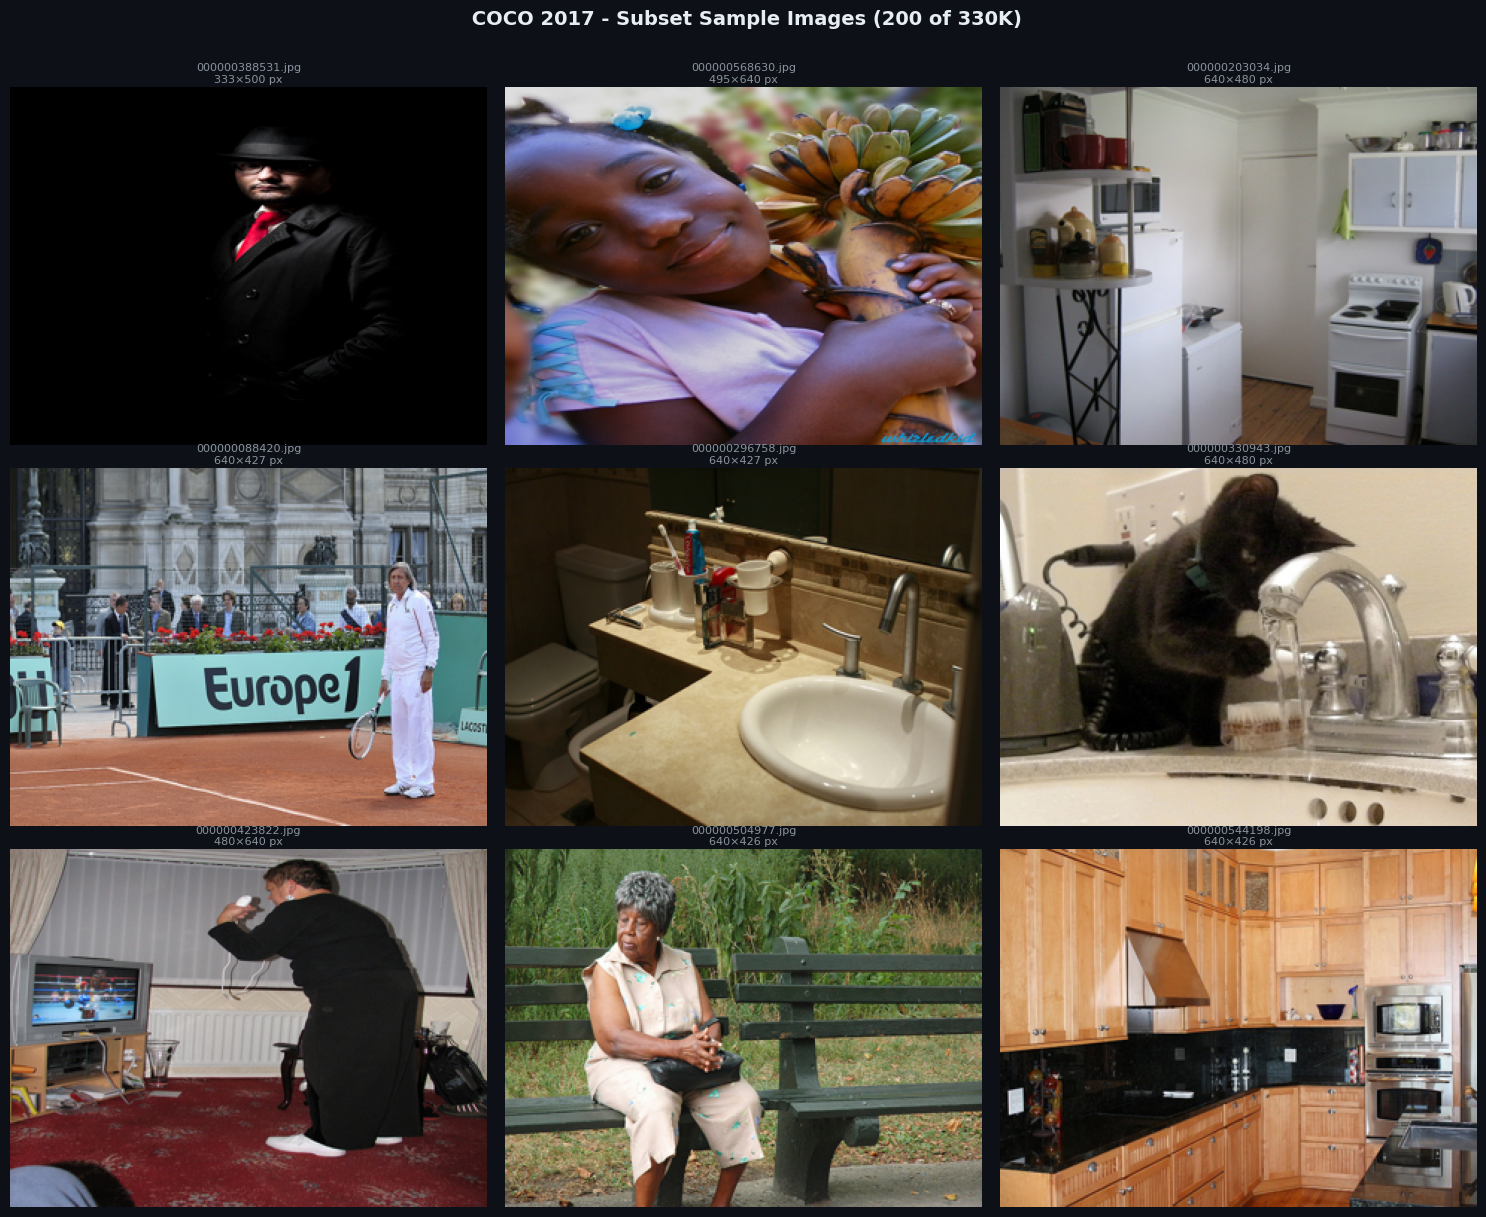

Saved → exports/coco_sample_images.png


In [16]:
# Visualize 9 sample COCO images
sample9 = random.sample(image_files, min(9, len(image_files)))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(' COCO 2017 - Subset Sample Images (200 of 330K)',
             fontsize=14, fontweight='bold', color='#e6edf3', y=1.01)

for ax, img_path in zip(axes.flatten(), sample9):
    try:
        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        ax.imshow(img.resize((320, 240)))
        ax.set_title(f'{os.path.basename(img_path)[:22]}\n{w}×{h} px',
                     fontsize=8, color='#8b949e', pad=3)
    except Exception as e:
        ax.text(0.5, 0.5, str(e)[:30], ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
    ax.axis('off')

for ax in axes.flatten()[len(sample9):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('exports/coco_sample_images.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → exports/coco_sample_images.png')

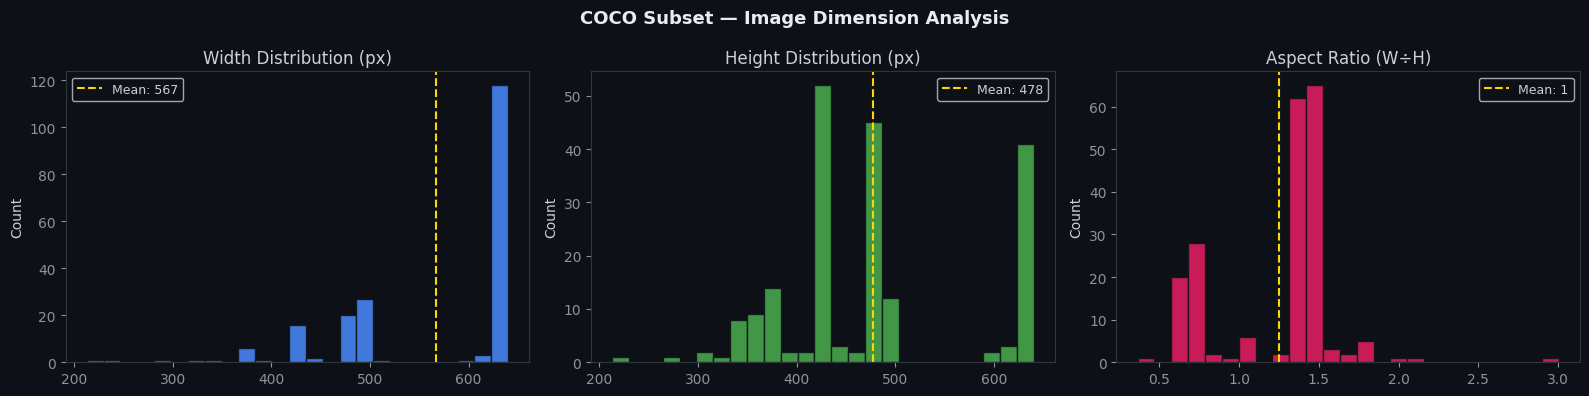

W — mean:567px  min:213  max:640
H — mean:478px  min:213  max:640
Landscape: 143/200


In [17]:
# Image dimension analysis
widths, heights, aspects = [], [], []
for f in image_files:
    try:
        w, h = Image.open(f).size
        widths.append(w); heights.append(h); aspects.append(round(w/h, 3))
    except:
        pass

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('COCO Subset — Image Dimension Analysis',
             fontsize=13, fontweight='bold', color='#e6edf3')

for ax, data, title, color in [
    (axes[0], widths,  'Width Distribution (px)',  '#4B8BFF'),
    (axes[1], heights, 'Height Distribution (px)', '#4CAF50'),
    (axes[2], aspects, 'Aspect Ratio (W÷H)',       '#E91E63'),
]:
    ax.hist(data, bins=25, color=color, edgecolor='#0d1117', alpha=.85)
    ax.axvline(np.mean(data), color='#FFD700', linestyle='--',
               linewidth=1.5, label=f'Mean: {np.mean(data):.0f}')
    ax.set_title(title, color='#c9d1d9')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('exports/image_dimension_analysis.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'W — mean:{np.mean(widths):.0f}px  min:{min(widths)}  max:{max(widths)}')
print(f'H — mean:{np.mean(heights):.0f}px  min:{min(heights)}  max:{max(heights)}')
print(f'Landscape: {sum(1 for a in aspects if a>1)}/{len(aspects)}')

Loading COCO annotations: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json
Found 23 bounding boxes for 4 images


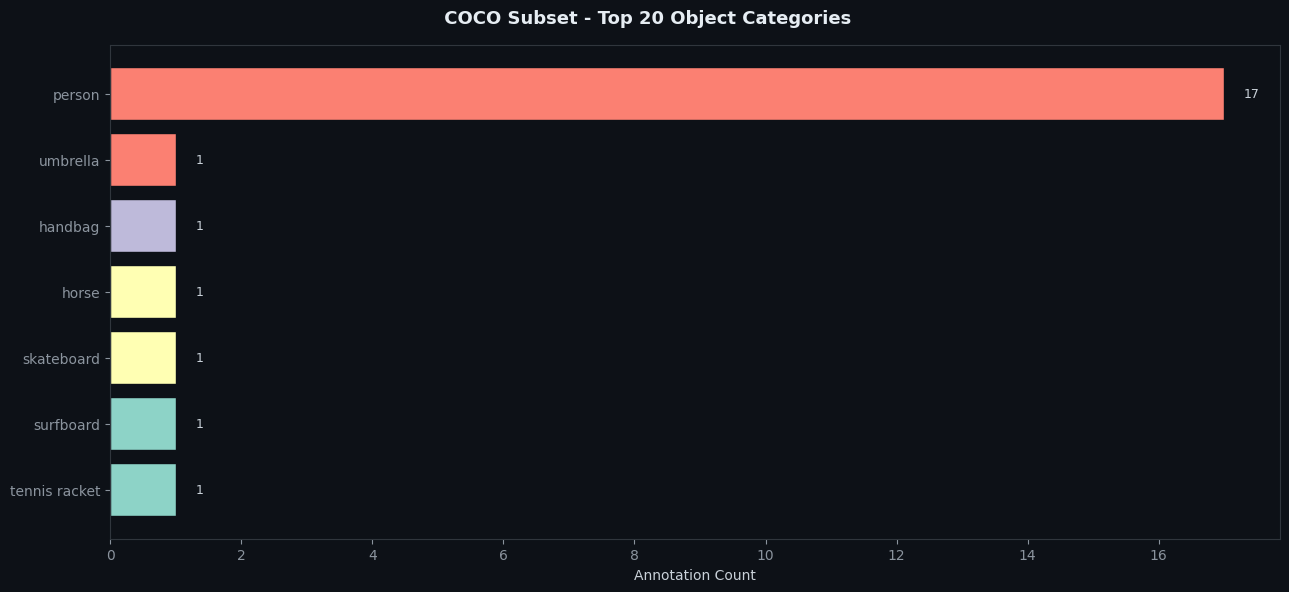

 Ground truth saved → data/images/coco_ground_truth.csv


In [18]:
# COCO bounding box ground truth (if annotation JSON found)
if COCO_ANN_PATH and os.path.exists(COCO_ANN_PATH):
    from collections import Counter
    print(f'Loading COCO annotations: {COCO_ANN_PATH}')

    with open(COCO_ANN_PATH) as f:
        coco_data = json.load(f)

    cat_lookup   = {c['id']: c['name'] for c in coco_data['categories']}
    subset_names = {os.path.basename(f) for f in image_files}
    subset_ids   = {img['id'] for img in coco_data['images']
                    if os.path.basename(img['file_name']) in subset_names}
    subset_anns  = [a for a in coco_data['annotations'] if a['image_id'] in subset_ids]

    print(f'Found {len(subset_anns):,} bounding boxes for {len(subset_ids)} images')

    cat_counts = Counter(cat_lookup.get(a['category_id'],'?') for a in subset_anns)
    top20 = cat_counts.most_common(20)

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.suptitle(' COCO Subset - Top 20 Object Categories',
                 fontsize=13, fontweight='bold', color='#e6edf3')
    wds, cnts = zip(*top20)
    pal = plt.cm.Set3(np.linspace(0, 1, 20))
    bars = ax.barh(list(wds)[::-1], list(cnts)[::-1], color=pal, edgecolor='#0d1117')
    ax.set_xlabel('Annotation Count')
    for bar, cnt in zip(bars, list(cnts)[::-1]):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                str(cnt), va='center', fontsize=9, color='#c9d1d9')
    plt.tight_layout()
    plt.savefig('exports/coco_category_dist.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

    # Save ground truth CSV
    df_gt = pd.DataFrame([{
        'image_id': a['image_id'],
        'category': cat_lookup.get(a['category_id'],'unknown'),
        'x_min':  round(a['bbox'][0],1), 'y_min':  round(a['bbox'][1],1),
        'width':  round(a['bbox'][2],1), 'height': round(a['bbox'][3],1),
        'area':   round(a['area'],1),
    } for a in subset_anns])
    df_gt.to_csv('data/images/coco_ground_truth.csv', index=False)
    print(f' Ground truth saved → data/images/coco_ground_truth.csv')
else:
    print('  COCO annotation JSON not available - image-only annotation mode')

## Step 6 - Text EDA (IMDB 50K Reviews)

In [19]:
# Load and clean
df_text = pd.read_csv('data/text/IMDB_Dataset.csv')
df_text.columns = [c.lower().strip() for c in df_text.columns]

# Standardize column names
col_map = {}
for c in df_text.columns:
    if any(k in c for k in ('review','text')): col_map[c] = 'review'
    if any(k in c for k in ('sentiment','label')): col_map[c] = 'sentiment'
df_text = df_text.rename(columns=col_map)

# Clean HTML + whitespace
df_text['review']     = df_text['review'].astype(str)\
                                          .str.replace(r'<[^>]+>',' ',regex=True)\
                                          .str.replace(r'\s+',' ',regex=True).str.strip()
df_text['sentiment']  = df_text['sentiment'].astype(str).str.lower().str.strip()
df_text['word_count'] = df_text['review'].apply(lambda x: len(x.split()))
df_text['char_count'] = df_text['review'].apply(len)

print(' IMDB Dataset Summary')
print('─' * 40)
print(f'   Total rows      : {len(df_text):,}')
print(f'   Columns         : {list(df_text.columns)}')
print(f'   Avg word count  : {df_text["word_count"].mean():.0f}')
print(f'   Avg char count  : {df_text["char_count"].mean():.0f}')
print(f'   Max word count  : {df_text["word_count"].max():,}')
print()
print(' Label Distribution:')
print(df_text['sentiment'].value_counts().to_string())
print()
print(df_text[['review','sentiment']].head(3).to_string())

 IMDB Dataset Summary
────────────────────────────────────────
   Total rows      : 50,000
   Columns         : ['review', 'sentiment', 'word_count', 'char_count']
   Avg word count  : 229
   Avg char count  : 1287
   Max word count  : 2,459

 Label Distribution:
sentiment
positive    25000
negative    25000

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

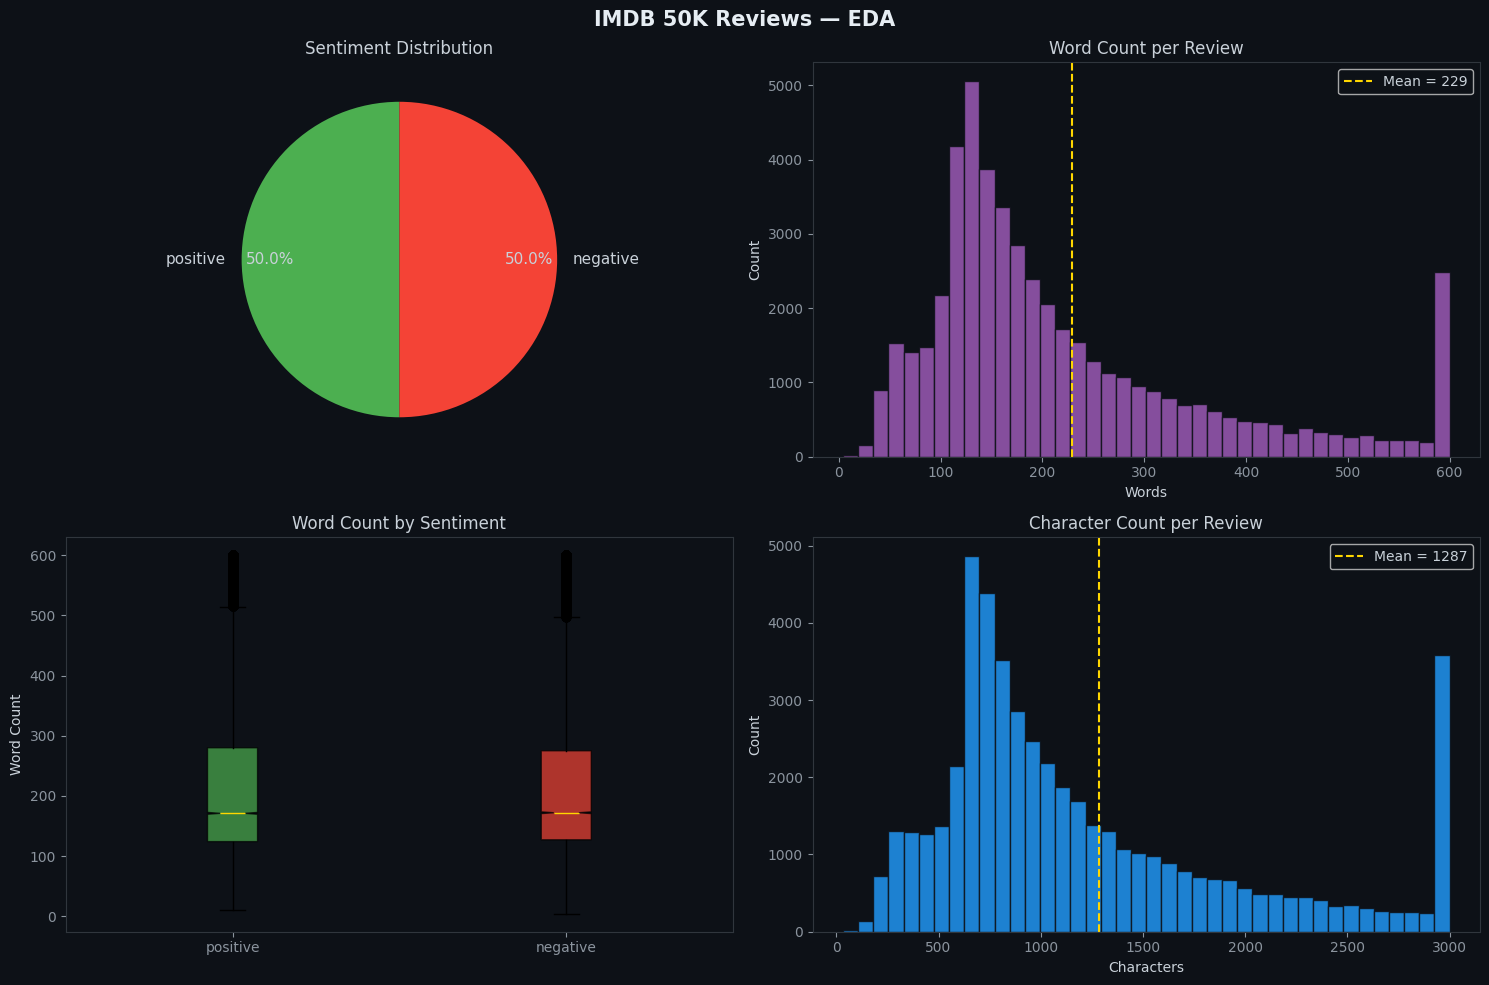

Saved → exports/imdb_eda.png


In [20]:
# EDA plots
import seaborn as sns

counts  = df_text['sentiment'].value_counts()
colors  = ['#4CAF50','#F44336','#FF9800']
sents   = counts.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('IMDB 50K Reviews — EDA', fontsize=15, fontweight='bold', color='#e6edf3')

# Pie
axes[0,0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
              colors=colors[:len(counts)], startangle=90, pctdistance=.82,
              textprops={'color':'#c9d1d9','fontsize':11})
axes[0,0].set_title('Sentiment Distribution', color='#c9d1d9', fontsize=12)

# Word count histogram
axes[0,1].hist(df_text['word_count'].clip(upper=600), bins=40,
               color='#9B59B6', edgecolor='#0d1117', alpha=.85)
axes[0,1].axvline(df_text['word_count'].mean(), color='#FFD700', linestyle='--',
                  linewidth=1.5, label=f'Mean = {df_text["word_count"].mean():.0f}')
axes[0,1].set_title('Word Count per Review', color='#c9d1d9', fontsize=12)
axes[0,1].set_xlabel('Words'); axes[0,1].set_ylabel('Count'); axes[0,1].legend()

# Box plot
grps = [df_text[df_text['sentiment']==s]['word_count'].clip(upper=600).values for s in sents]
bp   = axes[1,0].boxplot(grps, labels=sents, patch_artist=True, notch=True)
for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c); patch.set_alpha(.7)
[line.set_color('#FFD700') for line in bp['medians']]
axes[1,0].set_title('Word Count by Sentiment', color='#c9d1d9', fontsize=12)
axes[1,0].set_ylabel('Word Count')

# Char count
axes[1,1].hist(df_text['char_count'].clip(upper=3000), bins=40,
               color='#2196F3', edgecolor='#0d1117', alpha=.85)
axes[1,1].axvline(df_text['char_count'].mean(), color='#FFD700', linestyle='--',
                  linewidth=1.5, label=f'Mean = {df_text["char_count"].mean():.0f}')
axes[1,1].set_title('Character Count per Review', color='#c9d1d9', fontsize=12)
axes[1,1].set_xlabel('Characters'); axes[1,1].set_ylabel('Count'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('exports/imdb_eda.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → exports/imdb_eda.png')

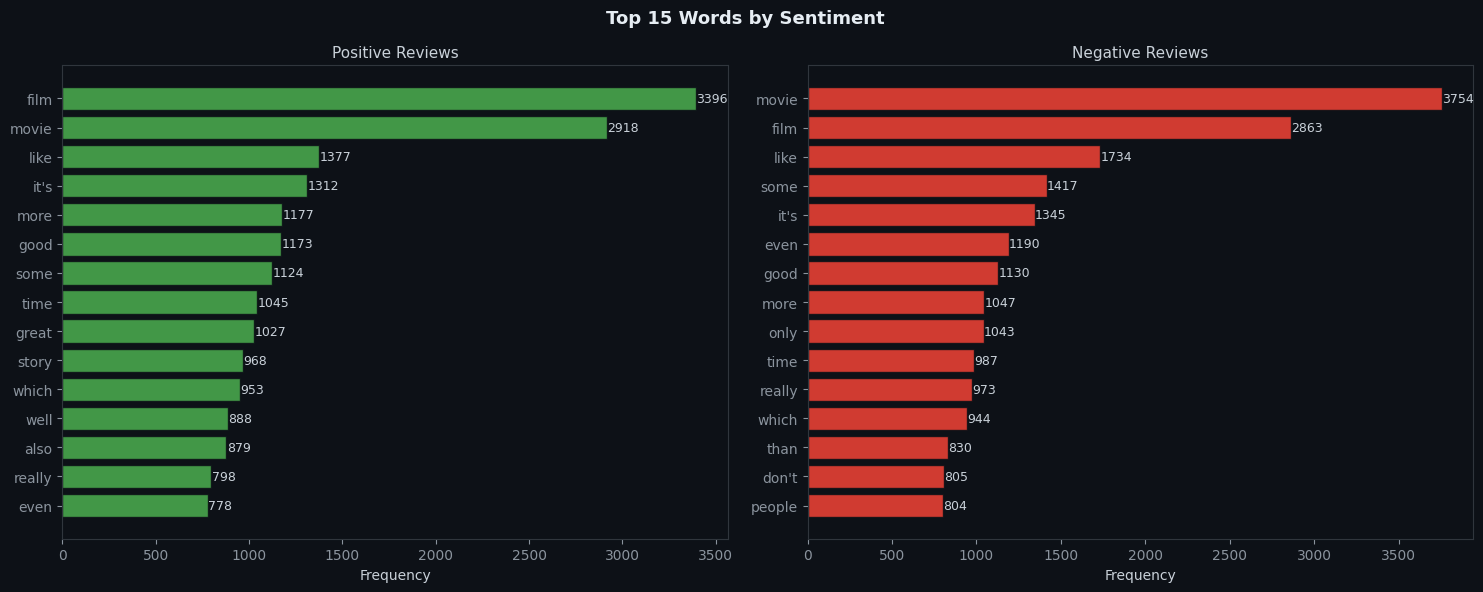

Saved → exports/imdb_top_words.png


In [21]:
# Top words by sentiment
from collections import Counter
STOP = {'the','a','an','and','or','but','in','on','at','to','for','of','with',
        'this','that','it','is','was','are','were','be','been','have','has','had',
        'do','does','did','will','would','could','should','i','me','my','we','you',
        'he','she','they','his','her','their','not','no','so','as','if','by','from',
        'up','about','very','its','what','just','then','when','there','here'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 15 Words by Sentiment', fontsize=13, fontweight='bold', color='#e6edf3')

for ax, (sentiment, color) in zip(axes, [('positive','#4CAF50'),('negative','#F44336')]):
    sample_size = min(2000, (df_text['sentiment']==sentiment).sum())
    corpus = ' '.join(df_text[df_text['sentiment']==sentiment]['review']\
                      .sample(sample_size, random_state=42)).lower()
    words  = [w.strip('.,!?;:"\'()[]') for w in corpus.split() if len(w)>3 and w not in STOP]
    top15  = Counter(words).most_common(15)
    if top15:
        wds, cnts = zip(*top15)
        bars = ax.barh(list(wds)[::-1], list(cnts)[::-1], color=color, edgecolor='#0d1117', alpha=.85)
        for bar, cnt in zip(bars, list(cnts)[::-1]):
            ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                    str(cnt), va='center', fontsize=9, color='#c9d1d9')
    ax.set_title(f'{sentiment.capitalize()} Reviews', color='#c9d1d9', fontsize=11)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('exports/imdb_top_words.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → exports/imdb_top_words.png')

In [22]:
# Stratified subset for annotation
ANNOTATION_N = 200
per_class    = ANNOTATION_N // df_text['sentiment'].nunique()

df_ann = df_text.groupby('sentiment', group_keys=False)\
    .apply(lambda x: x.sample(min(len(x), per_class), random_state=42))\
    .reset_index(drop=True)\
    .sample(frac=1, random_state=42).reset_index(drop=True)

df_ann[['review','sentiment']]\
    .rename(columns={'sentiment':'ground_truth'})\
    .to_csv('data/text/text_for_annotation.csv', index=False)

print(f' text_for_annotation.csv saved ({len(df_ann)} stratified rows)')
print(df_ann['sentiment'].value_counts().to_string())

 text_for_annotation.csv saved (200 stratified rows)
sentiment
negative    100
positive    100


## Step 7 - Audio EDA (RAVDESS)

In [23]:
df_audio = pd.read_csv('data/audio/audio_metadata.csv')

print(' RAVDESS Subset Summary')
print('─' * 40)
print(f'   Files    : {len(df_audio)}')
print(f'   Emotions : {df_audio["emotion"].nunique()}')
print(f'   Actors   : {df_audio["actor_id"].nunique()}')
print()
print('Emotion counts:')
print(df_audio['emotion'].value_counts().to_string())
print()
print(df_audio.head(6).to_string())

 RAVDESS Subset Summary
────────────────────────────────────────
   Files    : 96
   Emotions : 8
   Actors   : 24

Emotion counts:
emotion
surprised    12
neutral      12
disgust      12
fearful      12
sad          12
calm         12
happy        12
angry        12

                   filename    emotion  actor_id intensity  statement
0  03-01-08-02-01-02-02.wav  surprised         2    strong          1
1  03-01-08-01-02-02-21.wav  surprised        21    normal          2
2  03-01-08-01-02-01-13.wav  surprised        13    normal          2
3  03-01-08-01-01-02-13.wav  surprised        13    normal          1
4  03-01-08-02-02-02-16.wav  surprised        16    strong          2
5  03-01-08-01-01-01-22.wav  surprised        22    normal          1


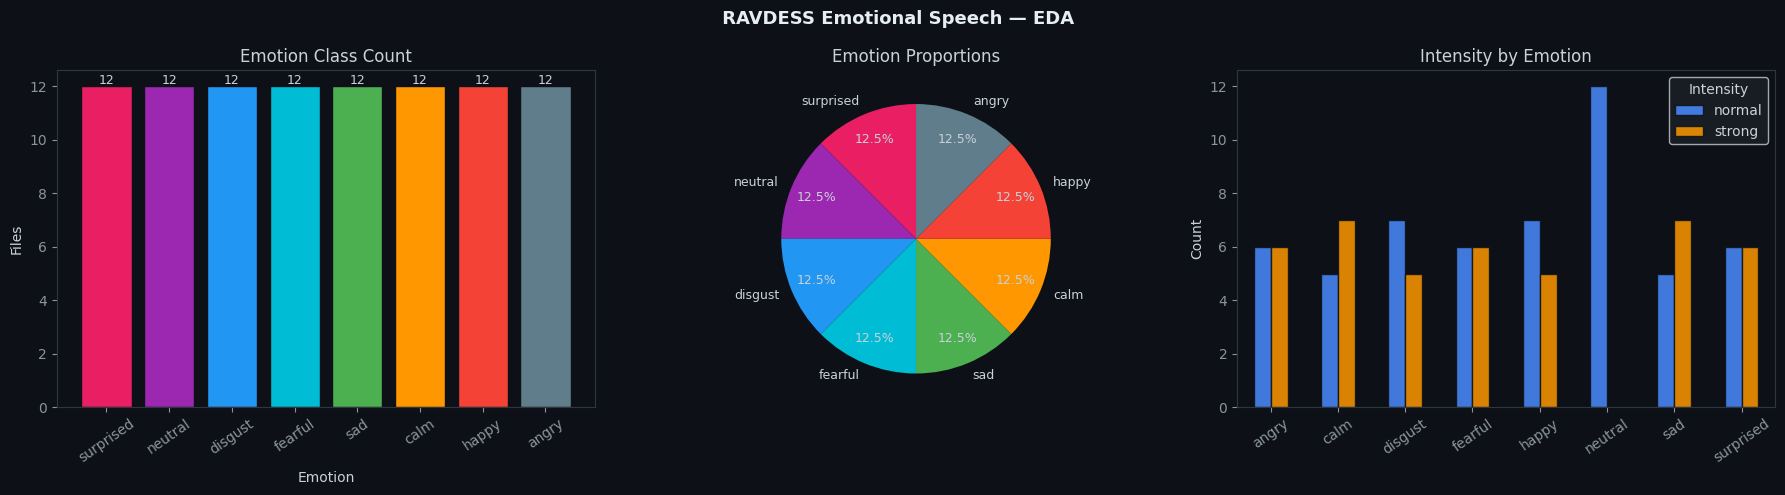

 Saved → exports/ravdess_eda.png


In [24]:
emo_counts = df_audio['emotion'].value_counts()
palette    = ['#E91E63','#9C27B0','#2196F3','#00BCD4','#4CAF50','#FF9800','#F44336','#607D8B']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(' RAVDESS Emotional Speech — EDA', fontsize=13, fontweight='bold', color='#e6edf3')

# Bar
bars = axes[0].bar(emo_counts.index, emo_counts.values,
                   color=palette[:len(emo_counts)], edgecolor='#0d1117')
axes[0].set_title('Emotion Class Count', color='#c9d1d9')
axes[0].set_xlabel('Emotion'); axes[0].set_ylabel('Files')
axes[0].tick_params(axis='x', rotation=35)
for bar, cnt in zip(bars, emo_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+.1,
                 str(cnt), ha='center', fontsize=9, color='#c9d1d9')

# Pie
axes[1].pie(emo_counts.values, labels=emo_counts.index, autopct='%1.1f%%',
            colors=palette[:len(emo_counts)], startangle=90, pctdistance=.80,
            textprops={'color':'#c9d1d9','fontsize':9})
axes[1].set_title('Emotion Proportions', color='#c9d1d9')

# Intensity breakdown
if 'intensity' in df_audio.columns:
    ie = df_audio.groupby(['emotion','intensity']).size().unstack(fill_value=0)
    ie.plot(kind='bar', ax=axes[2], color=['#4B8BFF','#FF9800'], edgecolor='#0d1117', alpha=.85)
    axes[2].set_title('Intensity by Emotion', color='#c9d1d9')
    axes[2].set_xlabel(''); axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=35)
    axes[2].legend(title='Intensity', facecolor='#1c2128', labelcolor='#c9d1d9')

plt.tight_layout()
plt.savefig('exports/ravdess_eda.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(' Saved → exports/ravdess_eda.png')

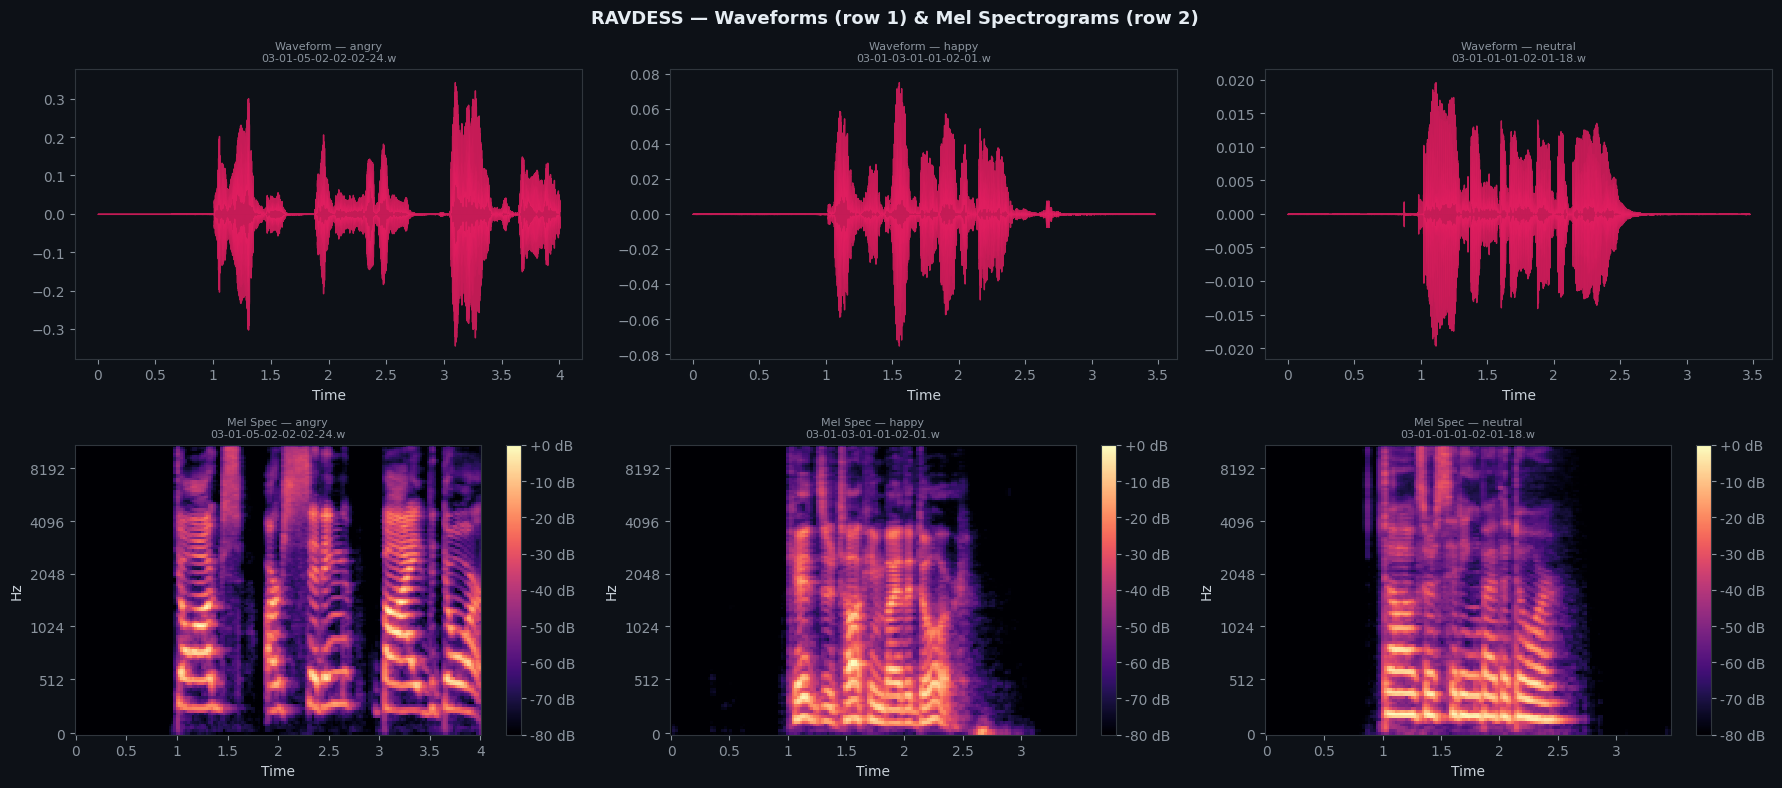

Saved → exports/ravdess_waveforms.png


In [25]:
# Waveform + Mel Spectrogram visualization
actual_wavs = glob.glob('data/audio/*.wav')

if actual_wavs:
    try:
        import librosa, librosa.display

        sample_wavs = random.sample(actual_wavs, min(6, len(actual_wavs)))
        emo_labels  = []
        for w in sample_wavs:
            parts = os.path.basename(w).replace('.wav','').split('-')
            emo_labels.append(RAVDESS_EMOTIONS.get(parts[2],'?') if len(parts)>=3 else '?')

        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        fig.suptitle('RAVDESS — Waveforms (row 1) & Mel Spectrograms (row 2)',
                     fontsize=13, fontweight='bold', color='#e6edf3')

        for i, (ax, wav_path, emo) in enumerate(zip(axes.flatten(), sample_wavs, emo_labels*2)):
            try:
                y, sr = librosa.load(wav_path, duration=4.0)
                if i < 3:
                    librosa.display.waveshow(y, sr=sr, ax=ax, color='#E91E63', alpha=.8)
                    ax.fill_between(np.linspace(0,len(y)/sr,len(y)), y, alpha=.15, color='#E91E63')
                    ax.set_title(f'Waveform — {emo}\n{os.path.basename(wav_path)[:22]}',
                                 fontsize=8, color='#8b949e')
                else:
                    idx  = i - 3
                    y2, sr2 = librosa.load(sample_wavs[idx], duration=4.0)
                    S    = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128)
                    Sdb  = librosa.power_to_db(S, ref=np.max)
                    img  = librosa.display.specshow(Sdb, sr=sr2, x_axis='time',
                                                    y_axis='mel', ax=ax, cmap='magma')
                    fig.colorbar(img, ax=ax, format='%+2.0f dB')
                    ax.set_title(f'Mel Spec — {emo_labels[idx]}\n{os.path.basename(sample_wavs[idx])[:22]}',
                                 fontsize=8, color='#8b949e')
                ax.set_facecolor('#0d1117')
            except Exception as e:
                ax.text(.5,.5,str(e)[:40],ha='center',va='center',transform=ax.transAxes,fontsize=7)
                ax.axis('off')

        plt.tight_layout()
        plt.savefig('exports/ravdess_waveforms.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
        plt.show()
        print('Saved → exports/ravdess_waveforms.png')

    except ImportError:
        print('librosa not installed — pip install librosa')
else:
    print('No .wav files in data/audio/ — metadata-only mode')

In [26]:
# MFCC Feature extraction
if actual_wavs:
    try:
        import librosa
        print('Extracting audio features (MFCC, RMS, ZCR)...')
        rows = []
        for f in actual_wavs[:60]:
            try:
                y, sr  = librosa.load(f, duration=3.0)
                mfccs  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                parts  = os.path.basename(f).replace('.wav','').split('-')
                emo    = RAVDESS_EMOTIONS.get(parts[2],'unknown') if len(parts)>=3 else 'unknown'
                rows.append({'filename':os.path.basename(f), 'emotion':emo,
                             'mfcc_mean':round(float(mfccs.mean()),4),
                             'mfcc_std': round(float(mfccs.std()),4),
                             'rms':      round(float(librosa.feature.rms(y=y).mean()),6),
                             'zcr':      round(float(librosa.feature.zero_crossing_rate(y).mean()),4),
                             'duration': round(len(y)/sr, 2)})
            except: pass
        df_feat = pd.DataFrame(rows)
        df_feat.to_csv('data/audio/audio_features.csv', index=False)
        print(f'Features extracted: {len(df_feat)} files → data/audio/audio_features.csv')
        print()
        print(df_feat.groupby('emotion')[['mfcc_mean','rms','duration']].mean().round(4).to_string())
    except ImportError:
        print('librosa not available — skipping feature extraction')
else:
    print('No wav files — skipping MFCC extraction')

Extracting audio features (MFCC, RMS, ZCR)...
Features extracted: 60 files → data/audio/audio_features.csv

           mfcc_mean     rms  duration
emotion                               
angry       -36.0171  0.0279       3.0
calm        -48.4884  0.0030       3.0
disgust     -44.6814  0.0058       3.0
fearful     -37.3947  0.0305       3.0
happy       -41.0394  0.0140       3.0
neutral     -49.4515  0.0060       3.0
sad         -42.8045  0.0077       3.0
surprised   -41.9746  0.0142       3.0


## Step 8 - Initialize SQLite Annotation Database

In [27]:
DB_PATH = 'annotations/annotations.db'
os.makedirs('annotations', exist_ok=True)

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.execute('''
    CREATE TABLE IF NOT EXISTS image_annotations (
        id         INTEGER PRIMARY KEY AUTOINCREMENT,
        image_file TEXT    NOT NULL,
        x_min      REAL, y_min REAL, x_max REAL, y_max REAL,
        label      TEXT,
        annotator  TEXT    DEFAULT "anonymous",
        confidence REAL    DEFAULT 1.0,
        time_taken REAL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )''')

cur.execute('''
    CREATE TABLE IF NOT EXISTS text_annotations (
        id                 INTEGER PRIMARY KEY AUTOINCREMENT,
        text_id            INTEGER,
        review             TEXT,
        ground_truth_label TEXT,
        annotator_label    TEXT,
        is_correct         INTEGER,
        annotator          TEXT    DEFAULT "anonymous",
        confidence         REAL    DEFAULT 1.0,
        time_taken         REAL,
        created_at         TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )''')

cur.execute('''
    CREATE TABLE IF NOT EXISTS audio_annotations (
        id                   INTEGER PRIMARY KEY AUTOINCREMENT,
        audio_file           TEXT NOT NULL,
        ground_truth_emotion TEXT,
        annotator_emotion    TEXT,
        transcription        TEXT,
        is_correct           INTEGER,
        annotator            TEXT DEFAULT "anonymous",
        confidence           REAL DEFAULT 1.0,
        time_taken           REAL,
        created_at           TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )''')

conn.commit()
conn.close()

print(f' SQLite database ready: {DB_PATH}')
print()
print('Tables:')
print('  image_annotations  — image_file | x_min y_min x_max y_max | label | annotator | confidence')
print('  text_annotations   — text_id | review | ground_truth | annotator_label | is_correct')
print('  audio_annotations  — audio_file | ground_truth_emotion | annotator_emotion | transcription')

 SQLite database ready: annotations/annotations.db

Tables:
  image_annotations  — image_file | x_min y_min x_max y_max | label | annotator | confidence
  text_annotations   — text_id | review | ground_truth | annotator_label | is_correct
  audio_annotations  — audio_file | ground_truth_emotion | annotator_emotion | transcription


## Step 9 - Test AI Suggestion Model (DistilBERT)

In [28]:
from transformers import pipeline

print('Loading DistilBERT sentiment model (~260 MB, cached after first download)...')
print()

AI_MODEL = None
try:
    AI_MODEL = pipeline(
        'sentiment-analysis',
        model='distilbert-base-uncased-finetuned-sst-2-english',
        truncation=True, max_length=512
    )
    print('Model loaded!')
    print()

    tests = [
        ('This movie was absolutely amazing. I loved every second!',    'positive'),
        ('Terrible film. Complete waste of time and money.',            'negative'),
        ('An average movie. Nothing special about it at all.',          'neutral'),
        ('One of the best performances I have seen. Outstanding work.', 'positive'),
        ('The worst script ever. Painfully bad from start to finish.',  'negative'),
    ]

    print('Model Test Results:')
    print('-' * 65)
    correct = 0
    for text, expected in tests:
        r        = AI_MODEL(text)[0]
        ai_lbl   = 'positive' if 'pos' in r['label'].lower() else 'negative'
        match    = '✅' if ai_lbl == expected else '⚠️ '
        icon     = '😊' if ai_lbl == 'positive' else '😞'
        correct += (ai_lbl == expected)
        print(f'  {match} {icon} {ai_lbl:<10} ({r["score"]:.1%}) | "{text[:44]}..."')
    print('-' * 65)
    print(f'  Test pass rate: {correct}/{len(tests)}')

except Exception as e:
    print(f' Model unavailable: {e}')
    print('   → app.py uses a rule-based keyword fallback — annotation still works!')

Loading DistilBERT sentiment model (~260 MB, cached after first download)...



config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Model loaded!

Model Test Results:
-----------------------------------------------------------------
  ✅ 😊 positive   (100.0%) | "This movie was absolutely amazing. I loved e..."
  ✅ 😞 negative   (100.0%) | "Terrible film. Complete waste of time and mo..."
  ⚠️  😞 negative   (100.0%) | "An average movie. Nothing special about it a..."
  ✅ 😊 positive   (100.0%) | "One of the best performances I have seen. Ou..."
  ✅ 😞 negative   (100.0%) | "The worst script ever. Painfully bad from st..."
-----------------------------------------------------------------
  Test pass rate: 4/5


## Step 10 - Annotation Quality Simulation

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

label_set    = ['positive','negative','neutral']
ground_truth = np.random.choice(label_set, 200, p=[0.5,0.4,0.1])

def simulate(gt, acc, bias_to=None):
    preds = []
    for g in gt:
        if random.random() < acc:
            preds.append(g)
        else:
            wrong = [l for l in label_set if l != g]
            preds.append(bias_to if bias_to and random.random()<.6 else random.choice(wrong))
    return preds

annotators = {
    'Annotator_A (Senior 92%)':    simulate(ground_truth, 0.92),
    'Annotator_B (Mid-level 84%)': simulate(ground_truth, 0.84),
    'Annotator_C (Junior 74%)':    simulate(ground_truth, 0.74, bias_to='positive'),
}

print('Annotator Performance')
print('=' * 52)
for name, preds in annotators.items():
    acc    = accuracy_score(ground_truth, preds)
    status = 'PASS' if acc>=.85 else 'REVIEW' if acc>=.75 else 'FAIL'
    print(f'  {name:<34} {acc:.1%}  {status}')
print('=' * 52)

Annotator Performance
  Annotator_A (Senior 92%)           93.5%  PASS
  Annotator_B (Mid-level 84%)        85.5%  PASS
  Annotator_C (Junior 74%)           82.5%  REVIEW


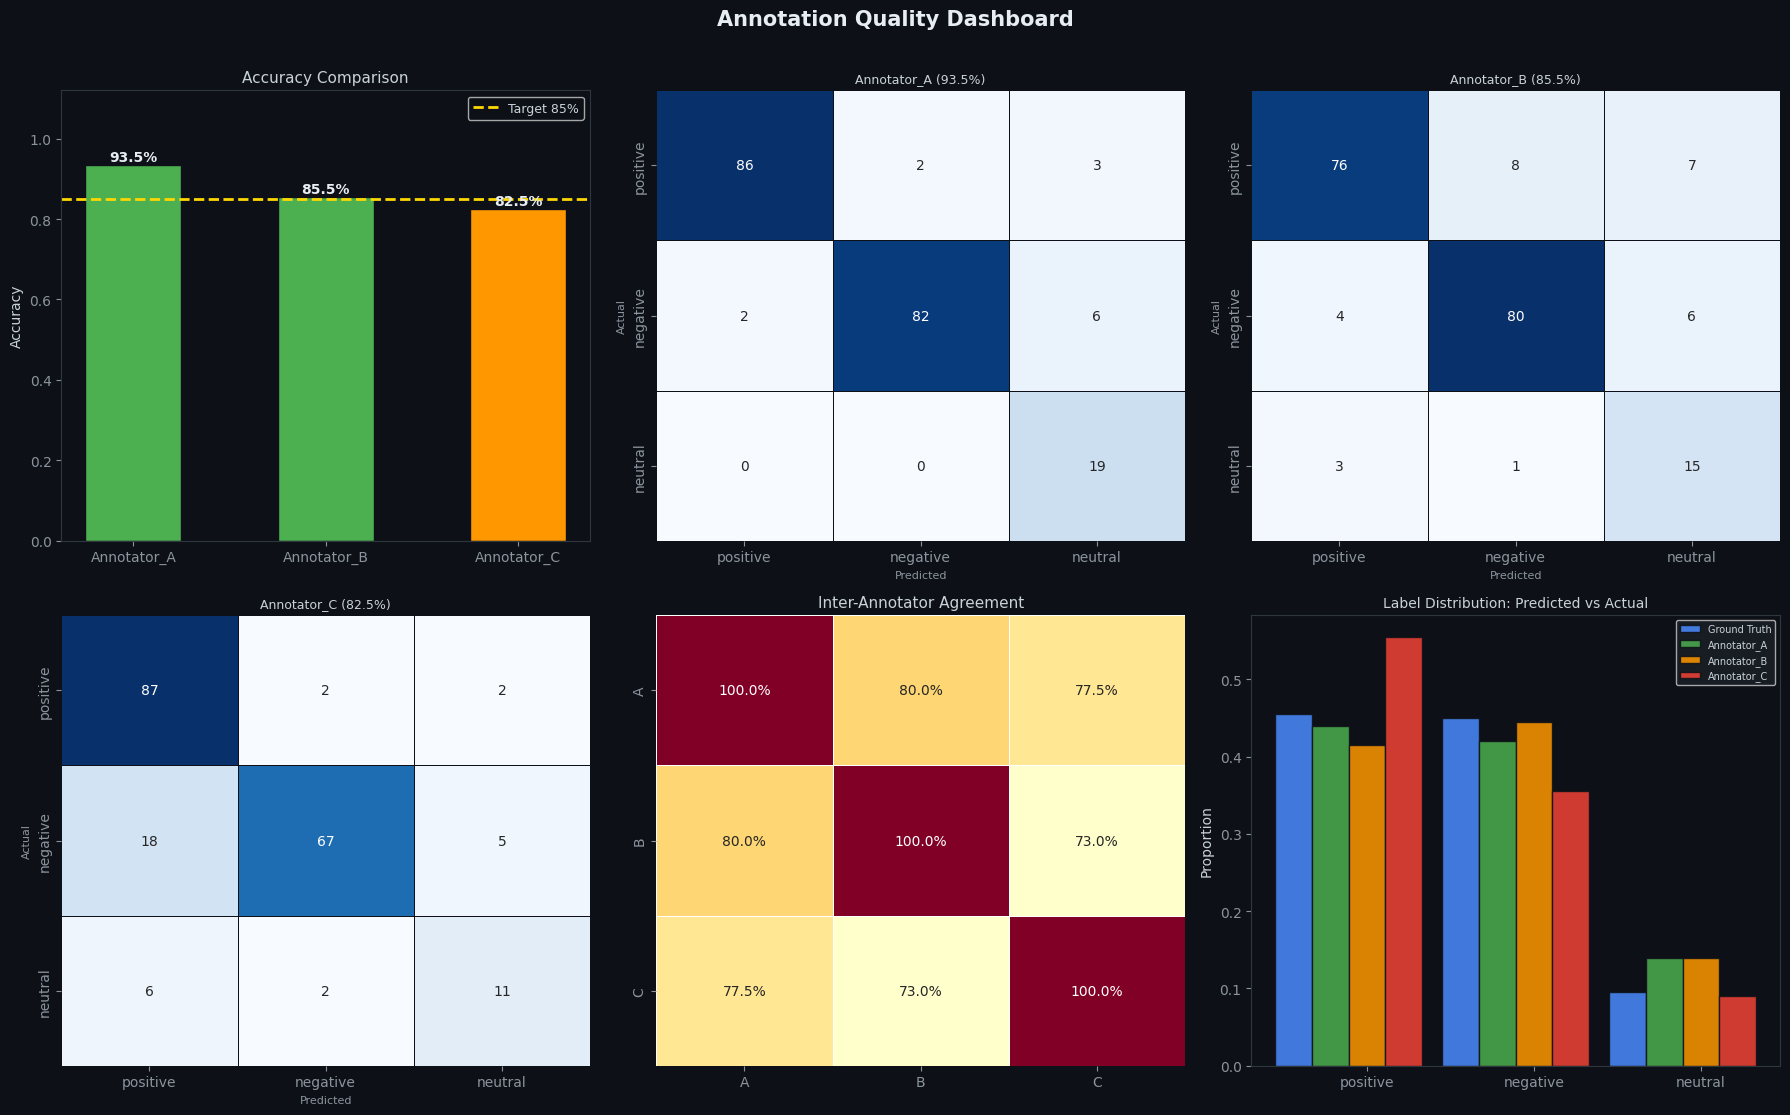

Saved → exports/quality_dashboard.png


In [31]:
ann_names   = list(annotators.keys())
ann_preds   = list(annotators.values())
accs        = [accuracy_score(ground_truth, p) for p in ann_preds]
bar_colors  = ['#4CAF50' if a>=.85 else '#FF9800' if a>=.75 else '#F44336' for a in accs]
clean_names = [n.split('(')[0].strip() for n in ann_names]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Annotation Quality Dashboard',
             fontsize=15, fontweight='bold', color='#e6edf3', y=1.01)

# 1. Accuracy bars
bars = axes[0,0].bar(clean_names, accs, color=bar_colors, edgecolor='#0d1117', width=.5)
axes[0,0].set_ylim(0, 1.12)
axes[0,0].axhline(.85, color='#FFD700', linestyle='--', linewidth=2, label='Target 85%')
axes[0,0].set_title('Accuracy Comparison', color='#c9d1d9', fontsize=11)
axes[0,0].set_ylabel('Accuracy'); axes[0,0].legend(fontsize=9)
for bar, acc in zip(bars, accs):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+.01,
                   f'{acc:.1%}', ha='center', fontweight='bold', color='#e6edf3')

# 2-4. Confusion matrices
for ax, (name, preds), acc in zip([axes[0,1], axes[0,2], axes[1,0]], annotators.items(), accs):
    cm = confusion_matrix(ground_truth, preds, labels=label_set)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_set, yticklabels=label_set,
                ax=ax, cbar=False, linewidths=.5, linecolor='#0d1117')
    ax.set_title(f'{name.split("(")[0].strip()} ({acc:.1%})', color='#c9d1d9', fontsize=9)
    ax.set_xlabel('Predicted', color='#8b949e', fontsize=8)
    ax.set_ylabel('Actual',    color='#8b949e', fontsize=8)
    ax.tick_params(colors='#8b949e')

# 5. Inter-annotator agreement
ag = np.array([[np.mean(np.array(pi)==np.array(pj)) for pj in ann_preds] for pi in ann_preds])
sns.heatmap(ag, annot=True, fmt='.1%', cmap='YlOrRd',
            xticklabels=['A','B','C'], yticklabels=['A','B','C'],
            ax=axes[1,1], cbar=False, linewidths=.5)
axes[1,1].set_title('Inter-Annotator Agreement', color='#c9d1d9', fontsize=11)
axes[1,1].tick_params(colors='#8b949e')

# 6. Label bias
x     = np.arange(len(label_set))
width = 0.22
actual_dist = [np.mean(np.array(ground_truth)==l) for l in label_set]
axes[1,2].bar(x-width, actual_dist, width, label='Ground Truth', color='#4B8BFF', edgecolor='#0d1117', alpha=.85)
for idx, (name, preds) in enumerate(annotators.items()):
    pd_dist = [np.mean(np.array(preds)==l) for l in label_set]
    axes[1,2].bar(x+idx*width, pd_dist, width,
                  label=name.split('(')[0].strip().split()[-1],
                  color=['#4CAF50','#FF9800','#F44336'][idx], edgecolor='#0d1117', alpha=.85)
axes[1,2].set_xticks(x+width); axes[1,2].set_xticklabels(label_set)
axes[1,2].set_title('Label Distribution: Predicted vs Actual', color='#c9d1d9', fontsize=10)
axes[1,2].set_ylabel('Proportion')
axes[1,2].legend(fontsize=7, facecolor='#1c2128', labelcolor='#c9d1d9')

plt.tight_layout()
plt.savefig('exports/quality_dashboard.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → exports/quality_dashboard.png')

In [32]:
print('Detailed Classification Report — Best Annotator (A):')
print('─' * 55)
print(classification_report(ground_truth, ann_preds[0], target_names=label_set))

Detailed Classification Report — Best Annotator (A):
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    positive       0.98      0.91      0.94        90
    negative       0.68      1.00      0.81        19
     neutral       0.98      0.95      0.96        91

    accuracy                           0.94       200
   macro avg       0.88      0.95      0.90       200
weighted avg       0.95      0.94      0.94       200



## Step 11 - Final Summary

In [33]:
n_images = len(glob.glob('data/images/coco_subset/*.jpg') + glob.glob('data/images/coco_subset/*.jpeg'))
n_text   = len(pd.read_csv('data/text/text_for_annotation.csv')) if os.path.exists('data/text/text_for_annotation.csv') else 0
n_audio  = len(pd.read_csv('data/audio/audio_metadata.csv'))     if os.path.exists('data/audio/audio_metadata.csv')     else 0
exports  = glob.glob('exports/*.png')

print('=' * 65)
print('SETUP COMPLETE - ML DATA ANNOTATION PLATFORM')
print('=' * 65)
print()
print('Datasets (downloaded via kagglehub):')
print(f'   COCO 2017 subset  : {n_images} images  → data/images/coco_subset/')
print(f'   IMDB Reviews       : {n_text} reviews → data/text/text_for_annotation.csv')
print(f'   RAVDESS Audio      : {n_audio} files  → data/audio/ + audio_metadata.csv')
print()
print(f' Database : annotations/annotations.db  (3 tables)')
print(f'EDA plots : {len(exports)} files saved in exports/')
for e in sorted(exports):
    print(f'   {os.path.basename(e)}')
print()
print('─' * 65)
print(' Launch the app:')
print()
print('   pip install -r requirements.txt')
print('   streamlit run app.py')
print()
print('App modules (all inside single app.py):')
print('   Image Annotation  → Bounding box on COCO images')
print('   Text Annotation   → Sentiment on IMDB reviews')
print('   Audio Annotation  → Emotion on RAVDESS audio')
print('   Dashboard         → KPIs, SLA gauge, CSV export')
print('=' * 65)

SETUP COMPLETE - ML DATA ANNOTATION PLATFORM

Datasets (downloaded via kagglehub):
   COCO 2017 subset  : 200 images  → data/images/coco_subset/
   IMDB Reviews       : 200 reviews → data/text/text_for_annotation.csv
   RAVDESS Audio      : 96 files  → data/audio/ + audio_metadata.csv

 Database : annotations/annotations.db  (3 tables)
EDA plots : 8 files saved in exports/
   coco_category_dist.png
   coco_sample_images.png
   image_dimension_analysis.png
   imdb_eda.png
   imdb_top_words.png
   quality_dashboard.png
   ravdess_eda.png
   ravdess_waveforms.png

─────────────────────────────────────────────────────────────────
 Launch the app:

   pip install -r requirements.txt
   streamlit run app.py

App modules (all inside single app.py):
   Image Annotation  → Bounding box on COCO images
   Text Annotation   → Sentiment on IMDB reviews
   Audio Annotation  → Emotion on RAVDESS audio
   Dashboard         → KPIs, SLA gauge, CSV export
